## Rough Bergomi Volatility
Train a neural network to replicate the mapping from Rough Bergomi parameters to implied volatility

In [1]:
import pandas as pd
import numpy as np
import torch
from torchvision import datasets, transforms
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.autograd import grad
from torch.utils.data import DataLoader, TensorDataset
from tqdm.auto import trange
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('seaborn-whitegrid')
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import os
from joblib import dump

In [2]:
if torch.cuda.is_available():
    device = torch.device("cuda:0")
else:
    device = torch.device("cpu")
print("Device:", device)

Device: cuda:0


### Load Data

In [3]:
base_filename = 'bergomi_option'

In [4]:
bergomi_data_list = list()
for i in range(0,100):
    filename = base_filename + str(i) + '.csv'
    if os.path.exists(filename):
        new_bergomi_data = pd.read_csv(filename, index_col=[0])
        bergomi_data_list.append(new_bergomi_data) 
    
bergomi_data = pd.concat(bergomi_data_list)
bergomi_data.reset_index(inplace=True)

In [5]:
bergomi_data.head()

,index,eta,rho,H,xi_0,tau,K,price,iv,time
0,0,3.243717,-0.935523,0.482178,0.099864,2.515086,0.740266,0.282512,0.193799,1.628941
1,1,2.471316,-0.467144,0.311337,0.106629,0.275032,0.525382,0.476859,0.626901,1.065817
2,2,3.878577,-0.353395,0.436474,0.081132,4.210174,1.124766,0.022479,0.077485,3.009489
3,3,3.021986,-0.280924,0.302770,0.039113,0.098784,1.082017,0.001982,0.175710,0.897997
4,4,1.053648,-0.407326,0.448916,0.067446,1.102567,0.889569,0.164990,0.254337,1.854213


In [6]:
y = bergomi_data['iv'].to_numpy()

In [7]:
X = bergomi_data.drop(['index','price', 'iv', 'time'], axis=1)

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.04, random_state=42)

In [9]:
standard_scaler = StandardScaler()
X_train = standard_scaler.fit_transform(X_train)
X_test = standard_scaler.transform(X_test)

In [10]:
dump(standard_scaler, 'rbergomi_scaler.bin', compress=True)

['rbergomi_scaler.bin']

In [11]:
batch_size = 1024

In [12]:
train_x = torch.Tensor(X_train).to(device)
train_y = torch.Tensor(y_train).to(device)
train_dataset = TensorDataset(train_x, train_y)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, 
                                           shuffle=True, drop_last=True)

test_x = torch.Tensor(X_test).to(device)
test_y = torch.Tensor(y_test).to(device)
test_dataset = TensorDataset(test_x, test_y)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, 
                                          shuffle=False, drop_last=True)

### Train Model

In [13]:
def train_model(model, train_loader, test_loader, loss_fn, optimizer, epochs):
    train_errors = []
    test_errors = []
    grad_errors = []

    tqdm_epoch = trange(epochs)
    for epoch in tqdm_epoch:
        model.train()
        train_loss = 0.0

        for batch_X, batch_y in train_loader:

            # Forward pass
            outputs = model(batch_X)
            loss = loss_fn(outputs.squeeze(), batch_y)

            # Backward pass and optimization
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * batch_X.size(0)

        train_loss /= len(train_loader.dataset)
        train_errors.append(train_loss)

        # Evaluation on the test set
        model.eval()
        test_loss = 0.0
        with torch.no_grad():
            for batch_X, batch_y in test_loader:
                outputs = model(batch_X)
                loss = loss_fn(outputs.squeeze(), batch_y)
                test_loss += loss.item() * batch_X.size(0)

        test_loss /= len(test_loader.dataset)
        test_errors.append(test_loss)

        tqdm_epoch.set_description(f"Epoch {epoch+1}/{epochs} - Train loss: {train_loss:.6f}, Test Loss: {test_loss:.6f}")
    history = dict()
    history['train_loss'] = train_errors
    history['test_loss'] = test_errors
    return history

In [14]:
class Swish(nn.Module):
    def __init__(self):
        super(Swish, self).__init__()

    def forward(self, x):
        return x * torch.sigmoid(x)

In [15]:
class NeuralNetwork(nn.Module):
    def __init__(self, width = 32, use_batch_norm=False):
        super(NeuralNetwork, self).__init__()
        self.use_batch_norm = use_batch_norm
        self.activation = Swish()
        self.fc1 = nn.Linear(6, width)
        self.bn1 = nn.BatchNorm1d(width) if use_batch_norm else nn.Identity()
        self.fc2 = nn.Linear(width, width)
        self.bn2 = nn.BatchNorm1d(width) if use_batch_norm else nn.Identity()
        self.fc3 = nn.Linear(width, width)
        self.bn3 = nn.BatchNorm1d(width) if use_batch_norm else nn.Identity()
        self.fc4 = nn.Linear(width, width)
        self.bn4 = nn.BatchNorm1d(width) if use_batch_norm else nn.Identity()
        self.fc5 = nn.Linear(width, 1)

    def forward(self, x):
        x = self.activation(self.bn1(self.fc1(x)))
        x = self.activation(self.bn2(self.fc2(x)))
        x = self.activation(self.bn3(self.fc3(x)))
        x = self.activation(self.bn4(self.fc4(x)))
        x = self.fc5(x)
        return x

In [18]:
no_epochs = 400
loss_fn = nn.MSELoss()

In [19]:
bergominn = NeuralNetwork(256, True).to(device)
optimizer = optim.Adam(bergominn.parameters(), lr=0.001)
history = train_model(bergominn, train_loader, test_loader, 
                          loss_fn, optimizer, no_epochs)

  0%|          | 0/400 [00:00<?, ?it/s]

In [20]:
model_path = "bergominn.pth"

In [21]:
torch.save(bergominn.state_dict(), model_path)

### Plot Losses

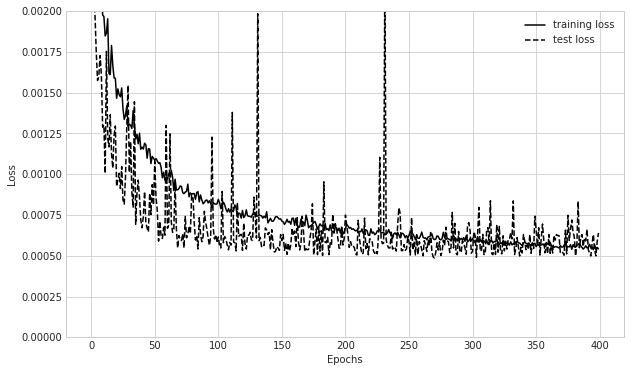

In [22]:
fig, ax = plt.subplots(figsize=(10,6))

train_loss_values = history['train_loss']
test_loss_values = history['test_loss']
ax.plot(train_loss_values, color='black', linestyle='-',label = 'training loss', )
ax.plot(test_loss_values, color='black', linestyle='--', label = 'test loss')

ax.set_xlabel('Epochs')
ax.set_ylabel('Loss')
ax.set_ylim(0,0.002)
ax.legend()
fig.savefig('BergomiNNLoss.png', dpi=300, bbox_inches='tight')

### Plot Sample Smiles

In [23]:
mats = np.round(np.linspace(0.1,5,8),1)
mats

array([0.1, 0.8, 1.5, 2.2, 2.9, 3.6, 4.3, 5. ])

In [24]:
strikes = np.round(np.linspace(0.7,1.3,11),1)
strikes

array([0.7, 0.8, 0.8, 0.9, 0.9, 1. , 1.1, 1.1, 1.2, 1.2, 1.3])

In [25]:
from py_vollib.black_scholes.implied_volatility import implied_volatility
import rbergomi

def rBergomiIV(S0, K, T, rho, eta, H, xi_0, num_paths, num_steps):
    a = H - 0.5
    rB = rbergomi.rBergomi(n = num_steps, N = num_paths, T = T, a = a)
    dW1 = rB.dW1()
    dW2 = rB.dW2()
    Y = rB.Y(dW1)
    dB = rB.dB(dW1, dW2, rho = rho)
    V = rB.V(Y, xi = xi_0, eta = eta)
    S = rB.S(V, dB)
    ST = S[:,-1][:,np.newaxis]
    call_payoff = np.maximum(ST - K,0)
    call_price = np.mean(call_payoff, axis = 0)[:,np.newaxis].item()
    iv = implied_volatility(call_price, S0, K, T, 0.0, 'c')
    return iv

In [39]:
S0 = 1
eta = 2.5
rho = -0.5
H = 0.25
xi_0 = 0.08

In [40]:
bergomi_smile_lst = list()

In [41]:
for imat in mats:
    smile_lst = list()
    for ik in strikes:
        iv = rBergomiIV(S0, ik, imat, rho, eta, H, xi_0, 30000, 100)
        smile_lst.append(iv)
    bergomi_smile_lst.append(smile_lst)

In [42]:
bergomi_smile = np.array(bergomi_smile_lst)
bergomi_smile

array([[0.51219695, 0.39574293, 0.40384271, 0.31523786, 0.30854577,
        0.25787453, 0.2346219 , 0.23529712, 0.25723815, 0.25192087,
        0.28744576],
       [0.32575968, 0.27725983, 0.28658019, 0.23578826, 0.23930856,
        0.20473669, 0.18912759, 0.19084662, 0.1958366 , 0.19236151,
        0.20513187],
       [0.27984651, 0.24483147, 0.24805085, 0.2116402 , 0.20774687,
        0.18423336, 0.1706669 , 0.17371734, 0.17211594, 0.17304312,
        0.18269683],
       [0.24684956, 0.22222936, 0.22004249, 0.19202286, 0.19130887,
        0.1673977 , 0.15443279, 0.15893212, 0.15524175, 0.15749179,
        0.16279924],
       [0.22179509, 0.20316458, 0.20129397, 0.17858024, 0.17555388,
        0.15495648, 0.14670968, 0.15223566, 0.14639582, 0.1455701 ,
        0.15508329],
       [0.21595562, 0.18749946, 0.18497696, 0.16520763, 0.16418447,
        0.14656205, 0.1364784 , 0.13488693, 0.13561092, 0.13782542,
        0.13970108],
       [0.20568249, 0.17612096, 0.17511497, 0.15596618, 0.

In [43]:
bergominn_smile_lst = list()

In [44]:
for imat in mats:
    for ik in strikes:
        input_lst = list()
        input_lst.append(eta)
        input_lst.append(rho)
        input_lst.append(H)
        input_lst.append(xi_0)
        input_lst.append(imat)
        input_lst.append(ik)
        bergominn_smile_lst.append(input_lst)

In [45]:
heading_list = ['eta', 'rho', 'H', 'xi_0', 'tau', 'K']
df = pd.DataFrame(bergominn_smile_lst, columns=heading_list)
df.head()

,eta,rho,H,xi_0,tau,K
0,2.5,-0.5,0.25,0.08,0.1,0.7
1,2.5,-0.5,0.25,0.08,0.1,0.8
2,2.5,-0.5,0.25,0.08,0.1,0.8
3,2.5,-0.5,0.25,0.08,0.1,0.9
4,2.5,-0.5,0.25,0.08,0.1,0.9


In [46]:
bergomi_X = standard_scaler.transform(df)

In [47]:
tbergomi_X = torch.Tensor(bergomi_X).to(device)

In [48]:
bergominn_iv = bergominn(tbergomi_X)

In [49]:
bergominn_iv = bergominn_iv.reshape((8, 11)).detach().cpu().numpy()

In [50]:
bergominn_iv

array([[0.4950854 , 0.3799541 , 0.3799541 , 0.3092314 , 0.3092314 ,
        0.24683715, 0.22472644, 0.22472644, 0.24405156, 0.24405156,
        0.27310774],
       [0.33027536, 0.28119734, 0.28119734, 0.23849055, 0.23849055,
        0.20391971, 0.18846607, 0.18846607, 0.19133157, 0.19133157,
        0.20260727],
       [0.28396416, 0.2432251 , 0.2432251 , 0.20984805, 0.20984805,
        0.18363692, 0.170796  , 0.170796  , 0.17088518, 0.17088518,
        0.17943421],
       [0.2528303 , 0.21828388, 0.21828388, 0.18956654, 0.18956654,
        0.16718522, 0.1556069 , 0.1556069 , 0.15642242, 0.15642242,
        0.16343355],
       [0.2327309 , 0.20355093, 0.20355093, 0.17767745, 0.17767745,
        0.15669286, 0.14594418, 0.14594418, 0.14697063, 0.14697063,
        0.15277584],
       [0.21709435, 0.19058678, 0.19058678, 0.16586581, 0.16586581,
        0.14677382, 0.13746037, 0.13746037, 0.13778666, 0.13778666,
        0.14254124],
       [0.2042584 , 0.17938016, 0.17938016, 0.15619074, 0.

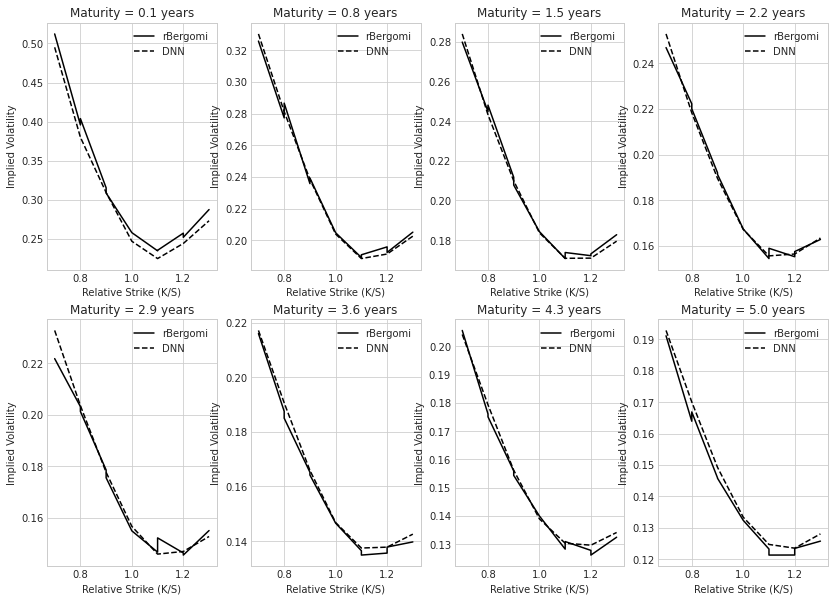

In [51]:
fig, axs = plt.subplots(2, 4, figsize=(14, 10))
axs = axs.flatten()

for i, maturity in enumerate(mats):
    axs[i].plot(strikes, bergomi_smile[i], color='black', linestyle = '-', label='rBergomi')
    axs[i].plot(strikes, bergominn_iv[i], color='black', linestyle = '--', label='DNN')
    axs[i].set_title(f'Maturity = {maturity} years')
    axs[i].set_xlabel('Relative Strike (K/S)')
    axs[i].set_ylabel('Implied Volatility')
    axs[i].legend()

fig.savefig('BergomiSmiles.png', dpi=300, bbox_inches='tight')